In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics
import seaborn as sns

df = pd.read_csv('raw_sales.csv')

In [9]:
df.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2612,278293,townhouse,5
1,2007-02-14 00:00:00,2602,341041,townhouse,4
2,2007-02-21 00:00:00,2905,467515,unit,2
3,2007-02-28 00:00:00,2602,260088,house,3
4,2007-03-07 00:00:00,2602,426000,townhouse,4


In [10]:
def find_anomalies(data):
    anomalies = []

    random_data_std = statistics.stdev(data)
    random_data_mean = statistics.mean(data)

    anomaly_cut_off = random_data_std * 3

    lower_limit = random_data_mean - anomaly_cut_off
    upper_limit = random_data_mean + anomaly_cut_off

    for outlier in data:
        if outlier > upper_limit or outlier < lower_limit:
            anomalies.append(outlier)

    return anomalies

In [11]:
data.price

0     278293
1     341041
2     467515
3     260088
4     426000
       ...  
95    359518
96    430039
97    362194
98    301888
99    282271
Name: price, Length: 100, dtype: int64

In [12]:
list_1= find_anomalies(data['price'])

In [13]:
len(list_1)


2

In [14]:
data.price.skew()

np.float64(2.3885681914707826)

<Axes: xlabel='price', ylabel='Density'>

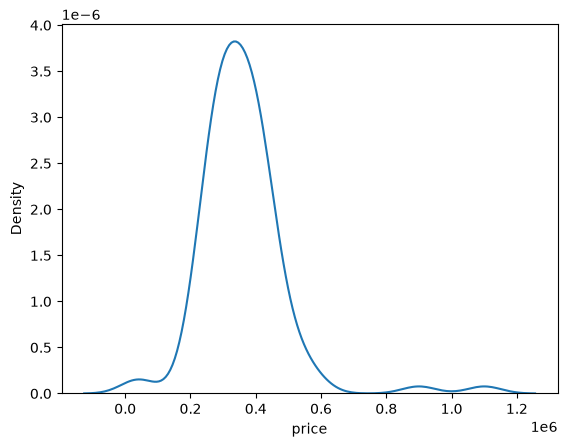

In [15]:
sns.kdeplot(data.price)

In [18]:
data['price_transformed']= np.log(data.price)
data.price_transformed.skew()

np.float64(-2.5964915538292543)